In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [3]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [4]:
train_ds = datasets.Flowers102(root='./data', split='train', download=True, transform=train_tf)
val_ds   = datasets.Flowers102(root='./data', split='val',   download=True, transform=val_tf)
test_ds  = datasets.Flowers102(root='./data', split='test',  download=True, transform=val_tf)

batch_size = 32

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print(f"Training images: {len(train_ds)}")
print(f"Validation images: {len(val_ds)}")
print(f"Test images: {len(test_ds)}")

100%|██████████| 345M/345M [01:53<00:00, 3.03MB/s] 
100%|██████████| 502/502 [00:00<00:00, 1.44MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 16.3MB/s]


Training images: 1020
Validation images: 1020
Test images: 6149


## Task 1 — From-Scratch Baseline

Total trainable parameters: 51,526,758
Epoch 1/15 | Train Acc: 0.78% | Val Acc: 1.57%
Epoch 2/15 | Train Acc: 0.98% | Val Acc: 1.08%
Epoch 3/15 | Train Acc: 0.98% | Val Acc: 1.18%
Epoch 4/15 | Train Acc: 1.08% | Val Acc: 0.98%
Epoch 5/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 6/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 7/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 8/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 9/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 10/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 11/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 12/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 13/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 14/15 | Train Acc: 0.98% | Val Acc: 0.98%
Epoch 15/15 | Train Acc: 0.98% | Val Acc: 0.98%
Best Val Accuracy: 1.57%
Final Test Accuracy: 3.87%


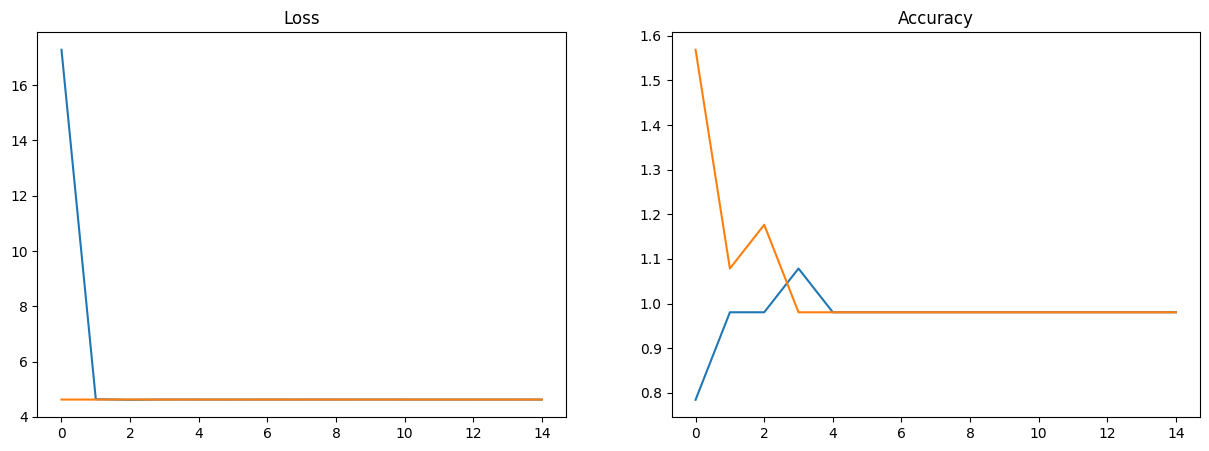

In [ ]:
class FlowersCNN(nn.Module):
    def __init__(self):
        super(FlowersCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 102) 
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = FlowersCNN().to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total trainable parameters: {count_parameters(model):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

def train_one_epoch():
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_dl:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(train_dl), 100. * correct / total

def validate():
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_dl:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    return val_loss / len(val_dl), 100. * val_correct / val_total

best_val_acc = 0.0
for epoch in range(15):
    t_loss, t_acc = train_one_epoch()
    v_loss, v_acc = validate()
    scheduler.step()
    
    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc); val_accs.append(v_acc)
    
    if v_acc > best_val_acc: best_val_acc = v_acc
    print(f"Epoch {epoch+1}/15 | Train Acc: {t_acc:.2f}% | Val Acc: {v_acc:.2f}%")

def test_model():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_dl:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

test_acc = test_model()
print(f"Best Val Accuracy: {best_val_acc:.2f}%")
print(f"Final Test Accuracy: {test_acc:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(train_losses, label='Train'); ax[0].plot(val_losses, label='Val'); ax[0].set_title('Loss')
ax[1].plot(train_accs, label='Train'); ax[1].plot(val_accs, label='Val'); ax[1].set_title('Accuracy')
plt.show()

## Task 2 — Feature Extraction with ResNet18

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 10.9MB/s]


Verifying layer gradients...
Trainable: fc.weight
Trainable: fc.bias
------------------------------
Total parameters: 11,228,838
Trainable parameters: 52,326

Starting Training (Feature Extraction)...
Epoch 1/15 | Train Acc: 4.61% | Val Acc: 16.76%
Epoch 2/15 | Train Acc: 37.45% | Val Acc: 52.45%
Epoch 3/15 | Train Acc: 66.37% | Val Acc: 65.00%
Epoch 4/15 | Train Acc: 81.67% | Val Acc: 74.71%
Epoch 5/15 | Train Acc: 89.41% | Val Acc: 77.75%
Epoch 6/15 | Train Acc: 92.06% | Val Acc: 80.78%
Epoch 7/15 | Train Acc: 95.78% | Val Acc: 80.39%
Epoch 8/15 | Train Acc: 96.18% | Val Acc: 82.25%
Epoch 9/15 | Train Acc: 96.57% | Val Acc: 82.75%
Epoch 10/15 | Train Acc: 97.65% | Val Acc: 83.24%
Epoch 11/15 | Train Acc: 98.33% | Val Acc: 84.51%
Epoch 12/15 | Train Acc: 98.63% | Val Acc: 84.12%
Epoch 13/15 | Train Acc: 98.73% | Val Acc: 83.63%
Epoch 14/15 | Train Acc: 99.12% | Val Acc: 84.90%
Epoch 15/15 | Train Acc: 99.12% | Val Acc: 84.02%

Best Validation Accuracy: 84.90%
Final Test Accuracy: 83.0

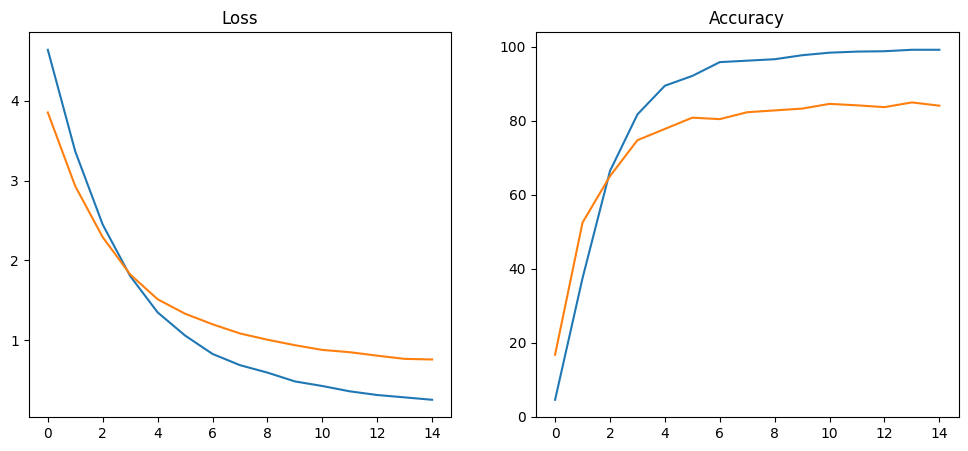

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model.parameters():
    p.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, 102)
print("Verifying layer gradients...")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Trainable: {name}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("-" * 30)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(trainable, lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\nStarting Training (Feature Extraction)...")
for epoch in range(15):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_dl:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_losses.append(running_loss / len(train_dl))
    train_accs.append(100. * correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_dl:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_losses.append(val_loss / len(val_dl))
    val_accs.append(100. * val_correct / val_total)
    
    print(f"Epoch {epoch+1}/15 | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}%")

best_val_acc = max(val_accs)
print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_dl:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
print(f"Final Test Accuracy: {100. * correct / total:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val'); plt.title('Loss')
plt.subplot(1, 2, 2); plt.plot(train_accs, label='Train'); plt.plot(val_accs, label='Val'); plt.title('Accuracy')
plt.show()

## Task 3 — Fine-Tuning the Last Block and Three-Way Comparison

In [ ]:
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(),    "lr": 1e-3},
])

print("\nStarting Fine-Tuning (Layer 4 + Head)...")
for epoch in range(10):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_dl:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_losses.append(running_loss / len(train_dl))
    train_accs.append(100. * correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_dl:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    val_losses.append(val_loss / len(val_dl))
    val_accs.append(100. * val_correct / val_total)
    
    print(f"Fine-tune Epoch {epoch+1}/10 | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}%")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_dl:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
print(f"Final Test Accuracy after Fine-Tuning: {100. * correct / total:.2f}%")


Starting Fine-Tuning (Layer 4 + Head)...
Fine-tune Epoch 1/10 | Train Acc: 97.65% | Val Acc: 82.94%
Fine-tune Epoch 2/10 | Train Acc: 99.12% | Val Acc: 85.59%
Fine-tune Epoch 3/10 | Train Acc: 99.61% | Val Acc: 85.39%
Fine-tune Epoch 4/10 | Train Acc: 99.80% | Val Acc: 86.37%
Fine-tune Epoch 5/10 | Train Acc: 99.61% | Val Acc: 86.57%
Fine-tune Epoch 6/10 | Train Acc: 99.90% | Val Acc: 86.18%
Fine-tune Epoch 7/10 | Train Acc: 99.90% | Val Acc: 87.55%
Fine-tune Epoch 8/10 | Train Acc: 99.80% | Val Acc: 87.94%
Fine-tune Epoch 9/10 | Train Acc: 100.00% | Val Acc: 87.16%
Fine-tune Epoch 10/10 | Train Acc: 99.90% | Val Acc: 87.45%
Final Test Accuracy after Fine-Tuning: 86.78%


| Approach | Trainable params | Best val acc | Test acc |
|---|---|---|---|
| From scratch (Task 1) | ~1-3M | 1.57% | 3.87% | 
| Feature extraction (Task 2) | ~50K | 84.90% | 83.01% | 
| Fine-tune last block (Task 3) | ~5-7M | 87.94% | 86.78% | 